In [ ]:
!jupyter nbconvert --to python coz.ipynb

In [127]:
!pip install pyreadstat

In [277]:
import pyreadstat
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score



In [279]:
df, meta = pyreadstat.read_sav('r32i_os_73.sav')

In [281]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11820 entries, 0 to 11819
Columns: 772 entries, idind to bbm111
dtypes: float64(771), object(1)
memory usage: 69.6+ MB


In [283]:
columns = {
    #bools features: 1- true 2-false
    # ДЕМОГРАФИЧЕСКИЕ ХАРАКТЕРИСТИКИ
    'bb_diplom': 'education_level',          # Уровень образования
    'bb_age': 'age',                         # Возраст респондента
    'bbh5': 'gender',                        # Пол (мужской/женский)
    
    # УДОВЛЕТВОРЕННОСТЬ ЖИЗНЬЮ
    'bbj65': 'life_satisfaction',            # Общая удовлетворенность жизнью
    'bbj66.1': 'financial_satisfaction',     # Удовлетворенность финансовым положением
    
    # ЛИЧНОСТНЫЕ ХАРАКТЕРИСТИКИ
    'bbj445.1': 'talkativeness',             # Разговорчивость
    'bbj445.2': 'work_accuracy',             # Точность в работе
    'bbj445.3': 'creativity',                # Креативность
    'bbj445.4': 'reserved_opinions',         # Сдержанность в выражении мнений
    'bbj445.5': 'stress_tolerance',          # Устойчивость к стрессу
    'bbj445.6': 'task_completion',          # Доведение задач до конца
    'bbj445.7': 'exploitability',           # Склонность позволять другим пользоваться собой
    'bbj445.8': 'work_ethic',               # Трудовая этика
    'bbj445.9': 'forgiveness',              # Способность прощать
    'bbj445.10': 'anxiety',                 # Тревожность
    'bbj445.11': 'curiosity',               # Любознательность
    'bbj445.12': 'preference_leisure',      # Предпочтение досуга работе
    'bbj445.13': 'long_term_focus',         # Ориентация на долгосрочные цели
    'bbj445.14': 'aesthetic_appreciation',  # Восприятие прекрасного
    'bbj445.15': 'future_orientation',      # Ориентация на будущее
    'bbj445.16': 'politeness',              # Вежливость
    'bbj445.17': 'work_efficiency',         # Эффективность в работе
    'bbj445.18': 'nervousness',             # Нервозность
    'bbj445.19': 'generosity',              # Щедрость
    'bbj445.20': 'sociability',             # Общительность
    'bbj445.21': 'decision_carefulness',    # Осторожность в принятии решений
    'bbj445.22': 'perceived_hostility',     # Воспринимаемая враждебность окружения
    
    # РИСКОВАННОЕ ПОВЕДЕНИЕ
    'bbj446': 'general_risk',             # Общая склонность к риску (0-10)
    'bbj447.1': 'driving_risk',             # Рискованное вождение
    'bbj447.2': 'financial_risk',           # Финансовый риск
    'bbj447.4': 'health_risk',              # Риск для здоровья
    'bbj447.5': 'health_risk_willingness',  # Готовность рисковать здоровьем
    'bbj448': 'future_sacrifice',           # Готовность отказаться от чего-то сегодня ради выгоды в будущем
    
    # ЗДОРОВЬЕ И АНТРОПОМЕТРИЯ
    'bbm1': 'weight_kg',                    # Вес в килограммах
    'bbm2': 'height_cm',                    # Рост в сантиметрах
    'bbm3': 'self_rated_health',            # Самооценка здоровья
    'bbm20.63': 'liver_disease',            # Наличие заболеваний печени
    'bbm20.64': 'kidney_disease',           # Наличие заболеваний почек
    'bbl58': 'recent_health_issues',        # Проблемы со здоровьем за последние 30 дней(Что Вы сделали, чтобы решить те проблемы со здоровьем, которые возникали у Вас в течение последних 30 дней?
#4 Не обращались к медработникам, занимались лечением самостоятельно
#5 Обращались в медицинские учреждения или просто к медработникам)
    
    # КУРЕНИЕ
    'bbm71': 'smoking_status',              # Текущий статус курения
    'bbm73': 'smoking_last_week',           # Курение в последние 7 дней
    'bbm75.1': 'cigarettes_per_day',        # Количество сигарет в день
    
    # АЛКОГОЛЬ (ОБЩИЕ ВОПРОСЫ)
    'bbm80': 'alcohol_use',                 # Употребление алкоголя
    'bbm80.0': 'alcohol_ever_used',         # Пробовал ли алкоголь
    'bbm82.1': 'alcohol_before_meal',       # Употребление алкоголя до еды
    'bbm82.3': 'alcohol_without_meal',      # Употребление алкоголя без еды
    'bbm83.2': 'alcohol_at_bars',           # Употребление в барах
    'bbm83.3': 'alcohol_outdoors',          # Употребление на улице
    'bbm83.4': 'alcohol_at_work',           # Употребление на работе
    'bbm83.5': 'alcohol_at_parties',        # Употребление на вечеринках
}

In [196]:
def unique_values_cols():
    for col in columns.values():
        print(col,' ---> ',df[col].unique())

In [201]:
col_arr = columns.values()

In [203]:
df = df[columns.keys()]

In [205]:
df

,bb_diplom,bb_age,bbh5,bbj65,bbj66.1,bbj445.1,bbj445.2,bbj445.3,bbj445.4,bbj445.5,...,bbm73,bbm75.1,bbm80,bbm80.0,bbm82.1,bbm82.3,bbm83.2,bbm83.3,bbm83.4,bbm83.5
0,3.0,79.0,2.0,4.0,3.0,2.0,2.0,3.0,1.0,2.0,...,NaN,NaN,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,4.0,65.0,2.0,2.0,4.0,4.0,1.0,3.0,1.0,3.0,...,NaN,NaN,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,69.5,1.0,2.0,2.0,2.0,2.0,2.0,2.0,4.0,...,NaN,NaN,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,95.5,2.0,2.0,2.0,4.0,2.0,4.0,2.0,1.0,...,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,69.0,2.0,2.0,2.0,2.0,2.0,3.0,3.0,1.0,...,NaN,NaN,1.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11815,2.0,84.5,2.0,2.0,2.0,3.0,2.0,3.0,2.0,2.0,...,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN
11816,5.0,20.5,2.0,1.0,3.0,2.0,1.0,3.0,2.0,1.0,...,1.0,99999996.0,1.0,1.0,2.0,1.0,1.0,2.0,2.0,1.0
11817,5.0,19.0,1.0,2.0,4.0,2.0,2.0,3.0,2.0,2.0,...,NaN,NaN,1.0,1.0,1.0,2.0,2.0,2.0,2.0,1.0
11818,4.0,58.0,1.0,2.0,2.0,3.0,1.0,3.0,1.0,2.0,...,1.0,30.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,1.0


In [207]:
df.rename(columns=columns, inplace=True)

In [209]:
df

,education_level,age,gender,life_satisfaction,financial_satisfaction,talkativeness,work_accuracy,creativity,reserved_opinions,stress_tolerance,...,smoking_last_week,cigarettes_per_day,alcohol_use,alcohol_ever_used,alcohol_before_meal,alcohol_without_meal,alcohol_at_bars,alcohol_outdoors,alcohol_at_work,alcohol_at_parties
0,3.0,79.0,2.0,4.0,3.0,2.0,2.0,3.0,1.0,2.0,...,NaN,NaN,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,4.0,65.0,2.0,2.0,4.0,4.0,1.0,3.0,1.0,3.0,...,NaN,NaN,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,69.5,1.0,2.0,2.0,2.0,2.0,2.0,2.0,4.0,...,NaN,NaN,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,95.5,2.0,2.0,2.0,4.0,2.0,4.0,2.0,1.0,...,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,69.0,2.0,2.0,2.0,2.0,2.0,3.0,3.0,1.0,...,NaN,NaN,1.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11815,2.0,84.5,2.0,2.0,2.0,3.0,2.0,3.0,2.0,2.0,...,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN
11816,5.0,20.5,2.0,1.0,3.0,2.0,1.0,3.0,2.0,1.0,...,1.0,99999996.0,1.0,1.0,2.0,1.0,1.0,2.0,2.0,1.0
11817,5.0,19.0,1.0,2.0,4.0,2.0,2.0,3.0,2.0,2.0,...,NaN,NaN,1.0,1.0,1.0,2.0,2.0,2.0,2.0,1.0
11818,4.0,58.0,1.0,2.0,2.0,3.0,1.0,3.0,1.0,2.0,...,1.0,30.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,1.0


In [211]:
col_arr_categorial = []
col_arr_numeric = []
col_arr_bool = []
for col in col_arr:
    if len(df[col].unique()) in (2,3):
        col_arr_bool.append(col)
    elif len(df[col].unique())<15:
        col_arr_categorial.append(col)
    else: col_arr_numeric.append(col)

In [213]:
col_arr_categorial

['education_level',
 'life_satisfaction',
 'financial_satisfaction',
 'talkativeness',
 'work_accuracy',
 'creativity',
 'reserved_opinions',
 'stress_tolerance',
 'task_completion',
 'exploitability',
 'work_ethic',
 'forgiveness',
 'anxiety',
 'curiosity',
 'preference_leisure',
 'long_term_focus',
 'aesthetic_appreciation',
 'future_orientation',
 'politeness',
 'work_efficiency',
 'nervousness',
 'generosity',
 'sociability',
 'decision_carefulness',
 'perceived_hostility',
 'self_rated_health',
 'liver_disease',
 'kidney_disease',
 'recent_health_issues',
 'smoking_status',
 'alcohol_use',
 'alcohol_ever_used',
 'alcohol_before_meal',
 'alcohol_without_meal',
 'alcohol_at_bars',
 'alcohol_outdoors',
 'alcohol_at_work',
 'alcohol_at_parties']

In [215]:
col_arr_numeric

['age',
 'general_risk',
 'driving_risk',
 'financial_risk',
 'health_risk',
 'health_risk_willingness',
 'future_sacrifice',
 'weight_kg',
 'height_cm',
 'cigarettes_per_day']

In [217]:
col_arr_bool

['gender', 'smoking_last_week']

In [219]:
unique_values_cols()

education_level  --->  [3.0000000e+00 4.0000000e+00 1.0000000e+00 5.0000000e+00 6.0000000e+00
 2.0000000e+00           nan 9.9999999e+07 9.9999998e+07 9.9999997e+07]
age  --->  [79.  65.  69.5 95.5 69.  70.5 47.5 60.  54.5 42.  59.5 61.  46.5 84.5
 73.  74.  77.  86.5 36.5 83.5 83.  58.5 41.5 37.5 52.  50.  38.  36.
 55.5 96.  72.  75.  51.5 85.5 78.  67.5 60.5 85.  53.  30.5 51.  43.5
 65.5 63.5 66.  71.5 64.  34.  76.5 81.5 87.5 59.  66.5 72.5 74.5 41.
 68.5 54.  70.  39.5 55.  81.  29.  82.  45.5 63.  64.5 62.  35.  62.5
 40.5 40.  52.5 33.  76.  53.5 57.5 30.  82.5 71.  35.5 56.5 67.  61.5
 58.  73.5 29.5 49.  32.  89.  91.5 28.5 57.  75.5 31.  80.5 86.  56.
 88.  80.  37.  46.  47.  38.5 49.5 48.  50.5 33.5 42.5 32.5 68.  77.5
 92.  88.5 45.  44.5 98.  84.  39.  90.5 90.  44.  34.5 31.5 78.5 48.5
 43.  89.5 94.5 92.5 79.5 87.  27.  28.  27.5 94.  25.  26.5 25.5 26.
 24.5 23.5 24.  23.  22.5 22.  95.  93.  21.  91.  21.5 20.  20.5 93.5
 19.5 19.  18.5 18.  17.  17.5 16.  16.5 15.5 

In [221]:
# Очистка данных от некорректных значений
df.replace({88888888: np.nan, 99999996: np.nan, 99999997: np.nan, 99999998: np.nan, 99999999: np.nan}, inplace=True)


In [223]:
unique_values_cols()

education_level  --->  [ 3.  4.  1.  5.  6.  2. nan]
age  --->  [79.  65.  69.5 95.5 69.  70.5 47.5 60.  54.5 42.  59.5 61.  46.5 84.5
 73.  74.  77.  86.5 36.5 83.5 83.  58.5 41.5 37.5 52.  50.  38.  36.
 55.5 96.  72.  75.  51.5 85.5 78.  67.5 60.5 85.  53.  30.5 51.  43.5
 65.5 63.5 66.  71.5 64.  34.  76.5 81.5 87.5 59.  66.5 72.5 74.5 41.
 68.5 54.  70.  39.5 55.  81.  29.  82.  45.5 63.  64.5 62.  35.  62.5
 40.5 40.  52.5 33.  76.  53.5 57.5 30.  82.5 71.  35.5 56.5 67.  61.5
 58.  73.5 29.5 49.  32.  89.  91.5 28.5 57.  75.5 31.  80.5 86.  56.
 88.  80.  37.  46.  47.  38.5 49.5 48.  50.5 33.5 42.5 32.5 68.  77.5
 92.  88.5 45.  44.5 98.  84.  39.  90.5 90.  44.  34.5 31.5 78.5 48.5
 43.  89.5 94.5 92.5 79.5 87.  27.  28.  27.5 94.  25.  26.5 25.5 26.
 24.5 23.5 24.  23.  22.5 22.  95.  93.  21.  91.  21.5 20.  20.5 93.5
 19.5 19.  18.5 18.  17.  17.5 16.  16.5 15.5 15.  14.5 14.  13.5 13.
 12.5 12.  11.5 11.  96.5 10.5  9.5 10.  97.5  9.   8.5  8.   7.5  7.
  6.5  6.   5.5  5.

In [225]:
print(df['general_risk'].isnull().sum())  # Количество пропусков
print(df['general_risk'].unique())  # Уникальные значения в столбце

2531
[ 0. 10.  3.  2.  6. nan  5.  4.  7.  8.  1.  9.]


In [227]:
for col in col_arr:
    if col in col_arr_numeric:
        df.fillna({col : int(df[col].mean())},inplace=True)
    elif col in col_arr_categorial:
        df.fillna({col : df[col].mode()[0]},inplace=True)
    elif col in col_arr_bool:
        df.fillna({col : df[col].mode()[0]},inplace=True)
    

In [229]:
unique_values_cols()

education_level  --->  [3. 4. 1. 5. 6. 2.]
age  --->  [79.  65.  69.5 95.5 69.  70.5 47.5 60.  54.5 42.  59.5 61.  46.5 84.5
 73.  74.  77.  86.5 36.5 83.5 83.  58.5 41.5 37.5 52.  50.  38.  36.
 55.5 96.  72.  75.  51.5 85.5 78.  67.5 60.5 85.  53.  30.5 51.  43.5
 65.5 63.5 66.  71.5 64.  34.  76.5 81.5 87.5 59.  66.5 72.5 74.5 41.
 68.5 54.  70.  39.5 55.  81.  29.  82.  45.5 63.  64.5 62.  35.  62.5
 40.5 40.  52.5 33.  76.  53.5 57.5 30.  82.5 71.  35.5 56.5 67.  61.5
 58.  73.5 29.5 49.  32.  89.  91.5 28.5 57.  75.5 31.  80.5 86.  56.
 88.  80.  37.  46.  47.  38.5 49.5 48.  50.5 33.5 42.5 32.5 68.  77.5
 92.  88.5 45.  44.5 98.  84.  39.  90.5 90.  44.  34.5 31.5 78.5 48.5
 43.  89.5 94.5 92.5 79.5 87.  27.  28.  27.5 94.  25.  26.5 25.5 26.
 24.5 23.5 24.  23.  22.5 22.  95.  93.  21.  91.  21.5 20.  20.5 93.5
 19.5 19.  18.5 18.  17.  17.5 16.  16.5 15.5 15.  14.5 14.  13.5 13.
 12.5 12.  11.5 11.  96.5 10.5  9.5 10.  97.5  9.   8.5  8.   7.5  7.
  6.5  6.   5.5  5.   4.5  4.

In [231]:
for col in col_arr:
    print(df[col].isnull().sum())

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [233]:
# 1. Демографические переменные
df['gender'] = df['gender'].map({1: 1, 2: 0})  # 1-муж, 0-жен
df['is_smoker'] = df['smoking_status'].map({1: 1, 2: 0, 3: 1})

# 2. Личностные характеристики - ПРЯМОЕ кодирование
direct_vars = ['talkativeness', 'work_accuracy', 'creativity', 'stress_tolerance', 
               'task_completion', 'work_ethic', 'forgiveness', 'curiosity',
               'long_term_focus', 'aesthetic_appreciation', 'future_orientation',
               'politeness', 'work_efficiency', 'generosity', 'sociability', 
               'decision_carefulness']

for var in direct_vars:
    if var in df.columns:
        df[var] = df[var].map({1: 4, 2: 3, 3: 2, 4: 1})  # 1->4, 4->1

# 3. Личностные характеристики - ОБРАТНОЕ кодирование 
reverse_vars = ['reserved_opinions', 'exploitability', 'anxiety', 'preference_leisure',
                'nervousness', 'perceived_hostility']


In [235]:
# ВЕСОВОЙ ПОДХОД: учитываем силу каждого маркера

def create_comprehensive_alcohol_index(df):
    """
    Создает комплексный индекс склонности к алкоголю от 0 до 10
    """
    df['alcohol_comprehensive_score'] = 0
    
    # 1. ПРЯМЫЕ АЛКОГОЛЬНЫЕ МАРКЕРЫ (наибольший вес)
    alcohol_markers = {
        'alcohol_use': 2,                    # Регулярное употребление
        'alcohol_at_work': 3,                # Пьет на работе - серьезный маркер
        'alcohol_without_meal': 2,           # Пьет без еды
        'alcohol_before_meal': 1,            # Пьет до еды
        'alcohol_outdoors': 1,               # Пьет на улице
    }
    
    for marker, weight in alcohol_markers.items():
        if marker in df.columns:
            df['alcohol_comprehensive_score'] += (df[marker] == 1).astype(int) * weight
    
    # 2. ДЕМОГРАФИЧЕСКИЕ ФАКТОРЫ РИСКА
    # Мужской пол - фактор риска
    if 'gender' in df.columns:
        df['alcohol_comprehensive_score'] += (df['gender'] == 1).astype(int) * 0.5
    
    # Молодой возраст - фактор риска (нормализуем возраст)
    if 'age' in df.columns:
        # Моложе 35 лет = риск, старше 55 = защита
        df['alcohol_comprehensive_score'] += ((df['age'] < 35).astype(int) * 0.5)
        df['alcohol_comprehensive_score'] -= ((df['age'] > 55).astype(int) * 0.5)
    
    # 3. КУРЕНИЕ - сильный коррелят
    if 'is_smoker' in df.columns:
        df['alcohol_comprehensive_score'] += (df['is_smoker'] == 1).astype(int) * 1.5
    
    # 4. РИСКОВОЕ ПОВЕДЕНИЕ
    risk_factors = {
        'general_risk': 0.1,           # Каждый балл общей склонности к риску
        'driving_risk': 1,             # Рискованное вождение
        'financial_risk': 0.5,         # Финансовый риск
    }
    
    for risk_var, weight in risk_factors.items():
        if risk_var in df.columns:
            if risk_var == 'general_risk':
                # Для общей склонности к риску используем числовое значение
                df['alcohol_comprehensive_score'] += df[risk_var].fillna(0) * weight
            else:
                df['alcohol_comprehensive_score'] += (df[risk_var] == 1).astype(int) * weight
    
    # 5. ЛИЧНОСТНЫЕ ЧЕРТЫ (на основе исследований)
    # Высокая импульсивность, низкая добросовестность
    if 'stress_tolerance' in df.columns:
        # Низкая устойчивость к стрессу = риск
        df['alcohol_comprehensive_score'] += ((df['stress_tolerance'] <= 2).astype(int) * 0.5)
    
    if 'task_completion' in df.columns:
        # Низкая добросовестность = риск
        df['alcohol_comprehensive_score'] += ((df['task_completion'] <= 2).astype(int) * 0.5)
    
    # Ограничиваем диапазон 0-10
    df['alcohol_comprehensive_score'] = df['alcohol_comprehensive_score'].clip(0, 10)
    
    return df

# Применяем функцию
df = create_comprehensive_alcohol_index(df)

In [237]:
# Преобразуем комплексный скор в бинарную целевую переменную
def create_final_target_variable(df, threshold=3.5):
    """
    Создает финальную бинарную целевую переменную
    threshold можно настроить в зависимости от распределения
    """
    # Сначала создаем категории на основе скора
    conditions = [
        df['alcohol_comprehensive_score'] <= 2,
        (df['alcohol_comprehensive_score'] > 2) & (df['alcohol_comprehensive_score'] <= 5),
        df['alcohol_comprehensive_score'] > 5
    ]
    
    choices = ['low_risk', 'medium_risk', 'high_risk']
    df['alcohol_risk_category'] = np.select(conditions, choices, default='unknown')
    
    # Бинарная целевая переменная (high_risk = 1, остальные = 0)
    df['alcohol_tendency_comprehensive'] = (df['alcohol_risk_category'] == 'high_risk').astype(int)
    
    return df

df = create_final_target_variable(df)



In [239]:
df


,education_level,age,gender,life_satisfaction,financial_satisfaction,talkativeness,work_accuracy,creativity,reserved_opinions,stress_tolerance,...,alcohol_before_meal,alcohol_without_meal,alcohol_at_bars,alcohol_outdoors,alcohol_at_work,alcohol_at_parties,is_smoker,alcohol_comprehensive_score,alcohol_risk_category,alcohol_tendency_comprehensive
0,3.0,79.0,0,4.0,3.0,3,3,2,1.0,3,...,1.0,2.0,2.0,2.0,2.0,1.0,0,0.5,low_risk,0
1,4.0,65.0,0,2.0,4.0,1,4,2,1.0,2,...,1.0,2.0,2.0,2.0,2.0,1.0,0,1.0,low_risk,0
2,4.0,69.5,1,2.0,2.0,3,3,3,2.0,1,...,1.0,2.0,2.0,2.0,2.0,1.0,0,2.5,medium_risk,0
3,1.0,95.5,0,2.0,2.0,1,3,1,2.0,4,...,1.0,2.0,2.0,2.0,2.0,1.0,0,2.5,medium_risk,0
4,5.0,69.0,0,2.0,2.0,3,3,2,3.0,4,...,2.0,2.0,1.0,2.0,2.0,1.0,0,1.5,low_risk,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11815,2.0,84.5,0,2.0,2.0,2,3,2,2.0,3,...,1.0,2.0,2.0,2.0,2.0,1.0,0,2.5,medium_risk,0
11816,5.0,20.5,0,1.0,3.0,3,4,2,2.0,4,...,2.0,1.0,1.0,2.0,2.0,1.0,1,6.5,high_risk,1
11817,5.0,19.0,1,2.0,4.0,3,3,2,2.0,3,...,1.0,2.0,2.0,2.0,2.0,1.0,0,4.5,medium_risk,0
11818,4.0,58.0,1,2.0,2.0,2,4,2,1.0,3,...,1.0,2.0,2.0,2.0,2.0,1.0,1,5.0,medium_risk,0


In [241]:
# Выбираем финальные признаки для модели
feature_columns = [
    # Демография
    'age', 'gender', 'education_level',
    
    # Личностные характеристики
    'talkativeness', 'work_accuracy', 'creativity', 'stress_tolerance',
    'task_completion', 'work_ethic', 'forgiveness', 'curiosity',
    'long_term_focus', 'aesthetic_appreciation', 'future_orientation',
    'politeness', 'work_efficiency', 'generosity', 'sociability',
    'decision_carefulness', 'reserved_opinions', 'exploitability',
    'anxiety', 'preference_leisure', 'nervousness', 'perceived_hostility',
    
    # Рисковое поведение
    'general_risk', 'driving_risk', 'financial_risk', 'health_risk',
    'future_sacrifice',
    
    # Здоровье и курение
    'self_rated_health', 'is_smoker'
]

# Убираем отсутствующие колонки
available_features = [col for col in feature_columns if col in df.columns]
print(f"Доступно признаков для модели: {len(available_features)}")

# Создаем финальный датасет для модели
X = df[available_features].select_dtypes(include=[np.number])
y = df['alcohol_tendency_comprehensive']

print(f"Размеры: X {X.shape}, y {y.shape}")

Доступно признаков для модели: 32
Размеры: X (11820, 32), y (11820,)


In [243]:
# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y  # сохраняем распределение целевой переменной
)

In [245]:
# Инициализация и обучение модели
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    class_weight='balanced'  # важно при несбалансированных данных
)

print("=== ОБУЧЕНИЕ МОДЕЛИ ===")
model.fit(X_train, y_train)

# Предсказания на тестовой выборке
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # вероятности для класса 1

# Оценка модели
print("\n=== ОЦЕНКА МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ ===")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.3f}")

=== ОБУЧЕНИЕ МОДЕЛИ ===

=== ОЦЕНКА МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ ===
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      2983
           1       0.53      0.75      0.62       563

    accuracy                           0.85      3546
   macro avg       0.74      0.81      0.77      3546
weighted avg       0.88      0.85      0.86      3546

Confusion Matrix:
[[2605  378]
 [ 139  424]]
ROC-AUC Score: 0.908


=== ТОП-20 ВАЖНЕЙШИХ ПРИЗНАКОВ ===
                 feature  importance
31             is_smoker      0.3385
0                    age      0.1307
1                 gender      0.1152
25          general_risk      0.0800
28           health_risk      0.0416
27        financial_risk      0.0305
26          driving_risk      0.0252
6       stress_tolerance      0.0226
7        task_completion      0.0181
29      future_sacrifice      0.0172
2        education_level      0.0124
13    future_orientation      0.0121
4          work_accuracy      0.0116
19     reserved_opinions      0.0105
8             work_ethic      0.0098
30     self_rated_health      0.0097
14            politeness      0.0093
18  decision_carefulness      0.0092
22    preference_leisure      0.0086
11       long_term_focus      0.0085


C:\Users\Sanya1337\AppData\Local\Temp\ipykernel_6960\3672750201.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_15, y='feature', x='importance', palette='viridis')


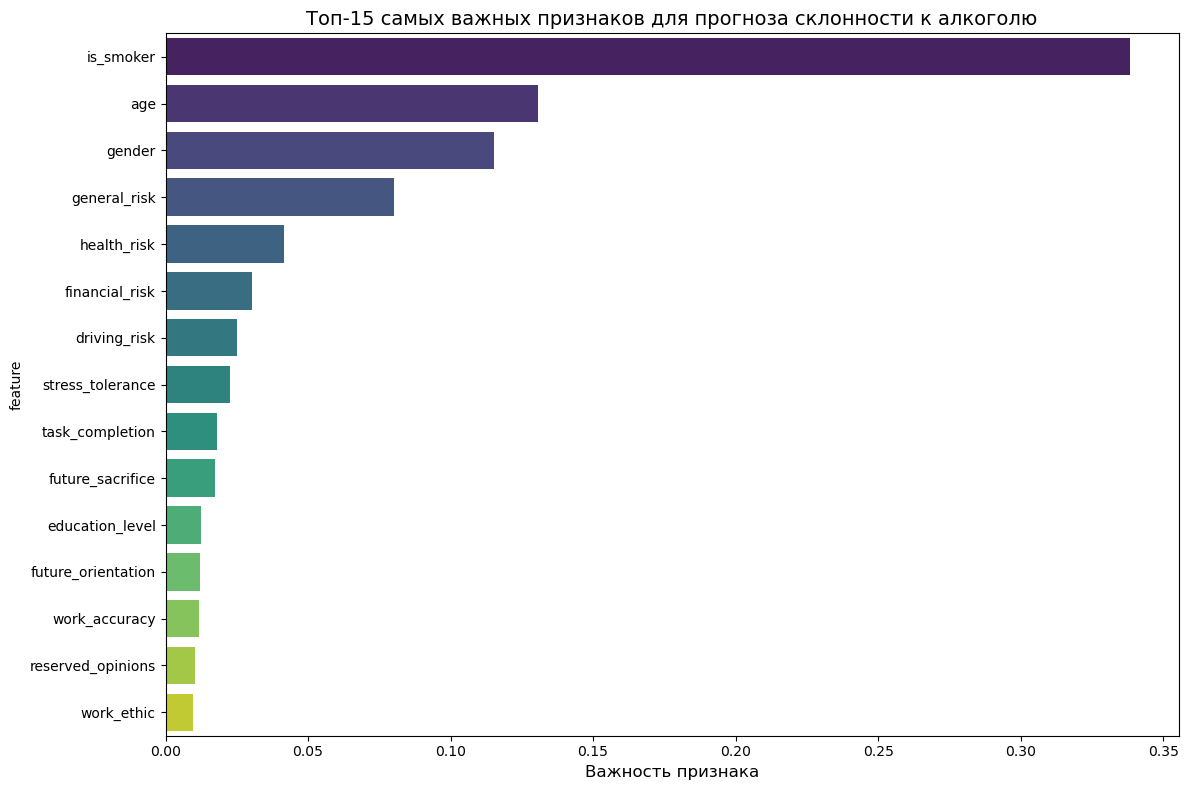

In [253]:
# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("=== ТОП-20 ВАЖНЕЙШИХ ПРИЗНАКОВ ===")
print(feature_importance.head(20).round(4))

# Визуализация
plt.figure(figsize=(12, 8))
top_15 = feature_importance.head(15)
sns.barplot(data=top_15, y='feature', x='importance', palette='viridis')
plt.title('Топ-15 самых важных признаков для прогноза склонности к алкоголю', fontsize=14)
plt.xlabel('Важность признака', fontsize=12)
plt.tight_layout()
plt.show()

In [257]:
print("=== 1. ДЕСКРИПТИВНАЯ СТАТИСТИКА ===")

# Распределение по полу
gender_dist = df['gender'].value_counts()
print("Распределение по полу:")
print(f"Мужчины: {gender_dist[1]} ({gender_dist[1]/len(df)*100:.1f}%)")
print(f"Женщины: {gender_dist[0]} ({gender_dist[0]/len(df)*100:.1f}%)")

# Доли со склонностью к алкоголю по полу
alcohol_by_gender = df.groupby('gender')['alcohol_tendency_comprehensive'].agg(['mean', 'count'])
print("\nДоля со склонностью к алкоголю:")
print(f"Мужчины: {alcohol_by_gender.loc[1, 'mean']:.3f} ({alcohol_by_gender.loc[1, 'mean']*100:.1f}%)")
print(f"Женщины: {alcohol_by_gender.loc[0, 'mean']:.3f} ({alcohol_by_gender.loc[0, 'mean']*100:.1f}%)")

# Разница в процентах
diff = alcohol_by_gender.loc[1, 'mean'] - alcohol_by_gender.loc[0, 'mean']
print(f"\nРазница: {diff:.3f} ({diff*100:.1f} процентных пункта)")

=== 1. ДЕСКРИПТИВНАЯ СТАТИСТИКА ===
Распределение по полу:
Мужчины: 5034 (42.6%)
Женщины: 6786 (57.4%)

Доля со склонностью к алкоголю:
Мужчины: 0.275 (27.5%)
Женщины: 0.073 (7.3%)

Разница: 0.201 (20.1 процентных пункта)


In [259]:
from statsmodels.stats.proportion import proportions_ztest

print("\n=== 2. Z-ТЕСТ ДЛЯ ДВУХ ПРОПОРЦИЙ ===")

# Подготовка данных для Z-теста
count = [alcohol_by_gender.loc[1, 'mean'] * alcohol_by_gender.loc[1, 'count'], 
         alcohol_by_gender.loc[0, 'mean'] * alcohol_by_gender.loc[0, 'count']]
nobs = [alcohol_by_gender.loc[1, 'count'], alcohol_by_gender.loc[0, 'count']]

# Z-тест
z_stat, p_value = proportions_ztest(count, nobs)
print(f"Z-статистика: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Интерпретация
if p_value < 0.05:
    print("✅ Разница СТАТИСТИЧЕСКИ ЗНАЧИМА - гипотеза подтверждается")
else:
    print("❌ Разница НЕ значима - гипотеза не подтверждается")


=== 2. Z-ТЕСТ ДЛЯ ДВУХ ПРОПОРЦИЙ ===
Z-статистика: 29.6235
P-value: 0.0000
✅ Разница СТАТИСТИЧЕСКИ ЗНАЧИМА - гипотеза подтверждается


In [261]:
print("\n=== 3. ОТНОШЕНИЕ ШАНСОВ (ODDS RATIO) ===")

# Расчет шансов
odds_men = alcohol_by_gender.loc[1, 'mean'] / (1 - alcohol_by_gender.loc[1, 'mean'])
odds_women = alcohol_by_gender.loc[0, 'mean'] / (1 - alcohol_by_gender.loc[0, 'mean'])
odds_ratio = odds_men / odds_women

print(f"Шансы для мужчин: {odds_men:.4f}")
print(f"Шансы для женщин: {odds_women:.4f}")
print(f"Отношение шансов (OR): {odds_ratio:.4f}")

# Интерпретация OR
if odds_ratio > 1:
    print(f"✅ Мужчины имеют в {odds_ratio:.2f} раза более высокие шансы склонности к алкоголю")
elif odds_ratio < 1:
    print(f"❌ Женщины имеют в {1/odds_ratio:.2f} раза более высокие шансы")
else:
    print("➖ Шансы равны")


=== 3. ОТНОШЕНИЕ ШАНСОВ (ODDS RATIO) ===
Шансы для мужчин: 0.3784
Шансы для женщин: 0.0789
Отношение шансов (OR): 4.7990
✅ Мужчины имеют в 4.80 раза более высокие шансы склонности к алкоголю


In [265]:
from scipy.stats import chi2_contingency

print("\n=== 4. ТЕСТ ХИ-КВАДРАТ ===")

# Создаем таблицу сопряженности
contingency_table = pd.crosstab(df['gender'], df['alcohol_tendency_comprehensive'])
print("Таблица сопряженности:")
print(contingency_table)

# Хи-квадрат тест
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"\nХи-квадрат: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Степени свободы: {dof}")

if p_value < 0.05:
    print("✅ Есть статистически значимая связь между полом и склонностью к алкоголю")
else:
    print("❌ Связь между полом и склонностью к алкоголю не значима")


=== 4. ТЕСТ ХИ-КВАДРАТ ===
Таблица сопряженности:
alcohol_tendency_comprehensive     0     1
gender                                    
0                               6290   496
1                               3652  1382

Хи-квадрат: 876.0459
P-value: 0.0000
Степени свободы: 1
✅ Есть статистически значимая связь между полом и склонностью к алкоголю


In [275]:
from scipy.stats import ttest_ind

print("\n=== 5. T-ТЕСТ ДЛЯ АЛКОГОЛЬНОГО ИНДЕКСА ===")

# Сравниваем alcohol_comprehensive_score
men_score = df[df['gender'] == 1]['alcohol_comprehensive_score'].dropna()
women_score = df[df['gender'] == 0]['alcohol_comprehensive_score'].dropna()

print(f"Средний алкогольный индекс:")
print(f"Мужчины: {men_score.mean():.3f} (std: {men_score.std():.3f})")
print(f"Женщины: {women_score.mean():.3f} (std: {women_score.std():.3f})")
print(f"Разница: {men_score.mean() - women_score.mean():.3f}")

# T-тест
t_stat, p_value = ttest_ind(men_score, women_score, equal_var=False)
print(f"\nT-статистика: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Средние алкогольные индексы значимо различаются")
else:
    print("❌ Разница в средних индексах не значима")


=== 5. T-ТЕСТ ДЛЯ АЛКОГОЛЬНОГО ИНДЕКСА ===
Средний алкогольный индекс:
Мужчины: 4.549 (std: 1.581)
Женщины: 3.324 (std: 1.324)
Разница: 1.226

T-статистика: 44.6175
P-value: 0.0000
✅ Средние алкогольные индексы значимо различаются



=== 6. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ===


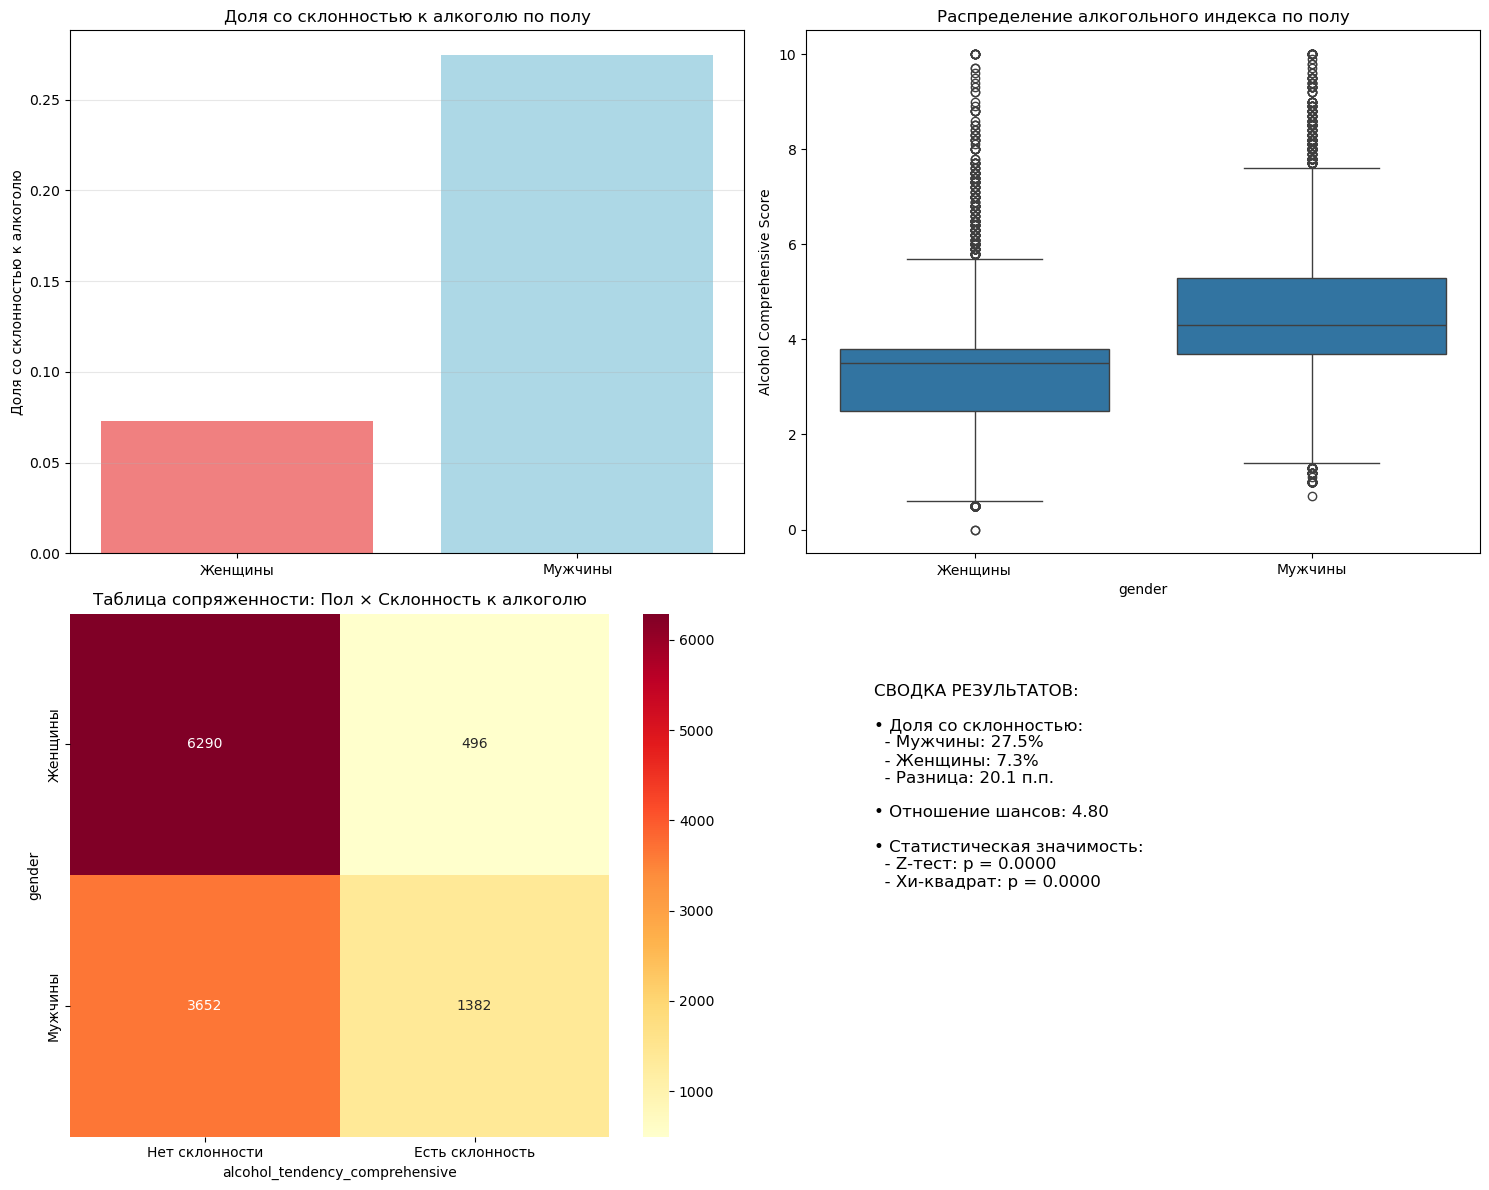

In [271]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n=== 6. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ===")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Столбчатая диаграмма долей
axes[0, 0].bar(['Женщины', 'Мужчины'], 
               [alcohol_by_gender.loc[0, 'mean'], alcohol_by_gender.loc[1, 'mean']],
               color=['lightcoral', 'lightblue'])
axes[0, 0].set_ylabel('Доля со склонностью к алкоголю')
axes[0, 0].set_title('Доля со склонностью к алкоголю по полу')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Boxplot алкогольного индекса
sns.boxplot(data=df, x='gender', y='alcohol_comprehensive_score', ax=axes[0, 1])
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(['Женщины', 'Мужчины'])
axes[0, 1].set_title('Распределение алкогольного индекса по полу')
axes[0, 1].set_ylabel('Alcohol Comprehensive Score')

# 3. Тепловая карта таблицы сопряженности
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1, 0])
axes[1, 0].set_title('Таблица сопряженности: Пол × Склонность к алкоголю')
axes[1, 0].set_xticklabels(['Нет склонности', 'Есть склонность'])
axes[1, 0].set_yticklabels(['Женщины', 'Мужчины'])

# 4. Сводка результатов
results_text = f"""
СВОДКА РЕЗУЛЬТАТОВ:

• Доля со склонностью:
  - Мужчины: {alcohol_by_gender.loc[1, 'mean']*100:.1f}%
  - Женщины: {alcohol_by_gender.loc[0, 'mean']*100:.1f}%
  - Разница: {diff*100:.1f} п.п.

• Отношение шансов: {odds_ratio:.2f}

• Статистическая значимость:
  - Z-тест: p = {p_value:.4f}
  - Хи-квадрат: p = {chi2_contingency(pd.crosstab(df['gender'], df['alcohol_tendency_comprehensive']))[1]:.4f}
"""

axes[1, 1].text(0.1, 0.9, results_text, fontsize=12, verticalalignment='top')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()